In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [38]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Select just 2 features
df = df[['petal length (cm)', 'petal width (cm)']]

print(df.head())


   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


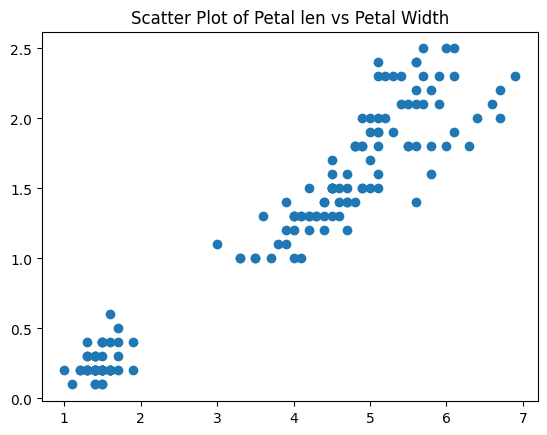

In [25]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'])
plt.title('Scatter Plot of Petal len vs Petal Width')
plt.show()

In [26]:
from sklearn.cluster import KMeans

In [28]:
X = df
y = iris['target']

In [29]:
wcss = []
for i in range(1,10):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42)
  km.fit(X)
  wcss.append(km.inertia_)


In [30]:
wcss

[550.8953333333333,
 86.39021984551391,
 31.371358974358966,
 19.48300089968511,
 13.91690875790876,
 11.443249546749545,
 9.607822488038277,
 8.661702759114524,
 7.580412433155081]

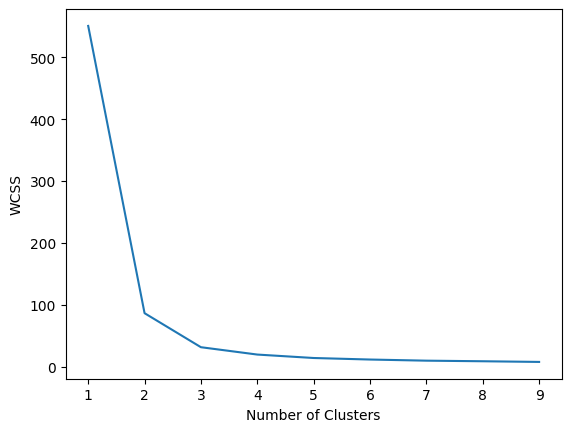

In [31]:
plt.plot(range(1,10),wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

* based on elbow method, elbow point = 3, i.e there should be 3 clusters.
* It can also be verified,since iris dataset have 3 species

In [34]:
km = KMeans(n_clusters=3)
y_means = km.fit_predict(X) #/model training

In [35]:
y_means

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

* Here 0, 1,2 represents three classes.

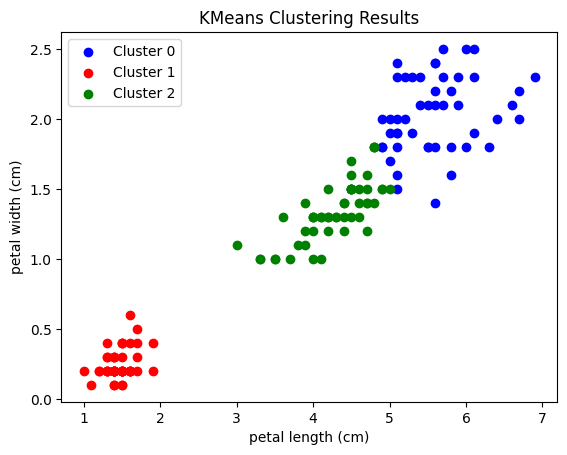

In [37]:
plt.scatter(X.iloc[y_means == 0, 0], X.iloc[y_means == 0, 1], color='blue', label='Cluster 0')
plt.scatter(X.iloc[y_means == 1, 0], X.iloc[y_means == 1, 1], color='red', label='Cluster 1')
plt.scatter(X.iloc[y_means == 2, 0], X.iloc[y_means == 2, 1], color='green', label='Cluster 2')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('KMeans Clustering Results')
plt.legend()
plt.show()